Using device: cpu

Lambda = 0.0001
Epoch 1/5 | Loss: 281.53
Epoch 2/5 | Loss: 244.46
Epoch 3/5 | Loss: 225.20
Epoch 4/5 | Loss: 210.65
Epoch 5/5 | Loss: 197.10
Accuracy: 0.5030
Sparsity: 0.00%

Lambda = 0.0005
Epoch 1/5 | Loss: 281.10
Epoch 2/5 | Loss: 244.84
Epoch 3/5 | Loss: 224.69
Epoch 4/5 | Loss: 209.78
Epoch 5/5 | Loss: 195.99
Accuracy: 0.4852
Sparsity: 0.00%

Lambda = 0.001
Epoch 1/5 | Loss: 281.97
Epoch 2/5 | Loss: 245.68
Epoch 3/5 | Loss: 225.90
Epoch 4/5 | Loss: 210.72
Epoch 5/5 | Loss: 196.42
Accuracy: 0.5040
Sparsity: 0.00%

Final Results:
Lambda	Accuracy	Sparsity
0.0001	0.5030		0.00%
0.0005	0.4852		0.00%
0.001	0.5040		0.00%


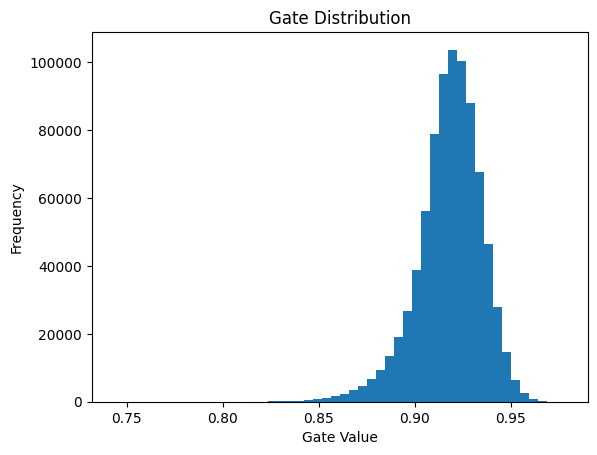

In [4]:
# =========================================
# SELF-PRUNING NETWORK (FINAL FIXED)
# =========================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# PRUNABLE LAYER
# -----------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # 🔥 FIX 1: lower init (important)
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features) * 0.5)

    def forward(self, x):
        # 🔥 FIX 2: sharper sigmoid
        gates = torch.sigmoid(self.gate_scores * 5)

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores * 5)


# -----------------------------
# MODEL (UNCHANGED)
# -----------------------------
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return torch.cat([
            self.fc1.get_gates().view(-1),
            self.fc2.get_gates().view(-1),
            self.fc3.get_gates().view(-1)
        ])


# -----------------------------
# DATA (UNCHANGED)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_subset = torch.utils.data.Subset(train_dataset, range(20000))
test_subset = torch.utils.data.Subset(test_dataset, range(5000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256)


# -----------------------------
# SPARSITY LOSS (FIXED)
# -----------------------------
def compute_sparsity_loss(model):
    gates = model.get_all_gates()

    # 🔥 FIX 3: stronger penalty
    return gates.mean() * 10


# -----------------------------
# TRAIN
# -----------------------------
def train_model(model, lambda_val, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            output = model(data)
            ce_loss = F.cross_entropy(output, target)

            sparsity_loss = compute_sparsity_loss(model)

            loss = ce_loss + lambda_val * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.2f}")


# -----------------------------
# TEST
# -----------------------------
def evaluate(model):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            pred = output.argmax(dim=1)

            correct += pred.eq(target).sum().item()

    return correct / len(test_subset)


# -----------------------------
# SPARSITY
# -----------------------------
def calculate_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates().detach().cpu().numpy()
    return (np.sum(gates < threshold) / gates.size) * 100


# -----------------------------
# RUN EXPERIMENTS
# -----------------------------
lambdas = [1e-4, 5e-4, 1e-3]

results = []
models = []

for lam in lambdas:
    print("\n========================")
    print(f"Lambda = {lam}")
    print("========================")

    model = PrunableNet().to(device)

    train_model(model, lam, epochs=5)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    print(f"Accuracy: {acc:.4f}")
    print(f"Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))
    models.append(model)


# -----------------------------
# RESULTS
# -----------------------------
print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")

for lam, acc, sp in results:
    print(f"{lam}\t{acc:.4f}\t\t{sp:.2f}%")


# -----------------------------
# PLOT
# -----------------------------
best_model = models[1]

gates = best_model.get_all_gates().detach().cpu().numpy()

plt.hist(gates, bins=50)
plt.title("Gate Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()